<a href="https://colab.research.google.com/github/greeshmakrishnan00/Machine-Learning/blob/main/Traffic_sign_Classification_ML_(KFold).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/traffic_sign_classification_dataset.csv')
df

,id,width,height,brightness,contrast,hue,saturation,sign_type,weather,damage_level,occlusion,label
0,1,122,129,0.008706,0.365804,228.210345,0.124825,Stop,Cloudy,2.0,Low,Warning
1,2,199,75,0.797767,0.599915,349.472316,0.028186,Yield,Foggy,0.0,Low,Informational
2,3,112,104,0.530358,0.620309,33.192252,0.244229,Stop,Foggy,4.0,Low,Mandatory
3,4,34,169,0.781212,0.434083,177.874897,0.843079,Pedestrian,Rainy,2.0,Medium,Informational
4,5,126,27,0.113927,0.929527,113.541535,0.646504,Stop,Cloudy,2.0,Low,Informational
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,136,140,0.714009,0.931464,298.103568,0.657095,Pedestrian,Foggy,1.0,Medium,Informational
49996,49997,86,138,0.147150,0.967653,157.641127,0.884586,No_Entry,Cloudy,4.0,NaN,Mandatory
49997,49998,81,142,0.750804,0.013123,112.406405,0.625332,Yield,Foggy,2.0,High,Mandatory
49998,49999,37,28,0.306993,0.856150,226.879129,0.188707,Yield,Sunny,NaN,Low,Prohibitory


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            50000 non-null  int64  
 1   width         50000 non-null  int64  
 2   height        50000 non-null  int64  
 3   brightness    50000 non-null  float64
 4   contrast      50000 non-null  float64
 5   hue           50000 non-null  float64
 6   saturation    50000 non-null  float64
 7   sign_type     50000 non-null  object 
 8   weather       50000 non-null  object 
 9   damage_level  39949 non-null  float64
 10  occlusion     40088 non-null  object 
 11  label         50000 non-null  object 
dtypes: float64(5), int64(3), object(4)
memory usage: 4.6+ MB


In [ ]:
df.isnull().sum()

,0
id,0
width,0
height,0
brightness,0
contrast,0
hue,0
saturation,0
sign_type,0
weather,0
damage_level,10051


In [ ]:
df["damage_level"].fillna(df["damage_level"].mode()[0],inplace=True)

/tmp/ipykernel_3123/4071087515.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["damage_level"].fillna(df["damage_level"].mode()[0],inplace=True)


In [ ]:
df["occlusion"].fillna(df["occlusion"].mode()[0],inplace=True)

/tmp/ipykernel_3123/4288128656.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["occlusion"].fillna(df["occlusion"].mode()[0],inplace=True)


In [ ]:
df.duplicated().sum()

np.int64(0)

# Visualization

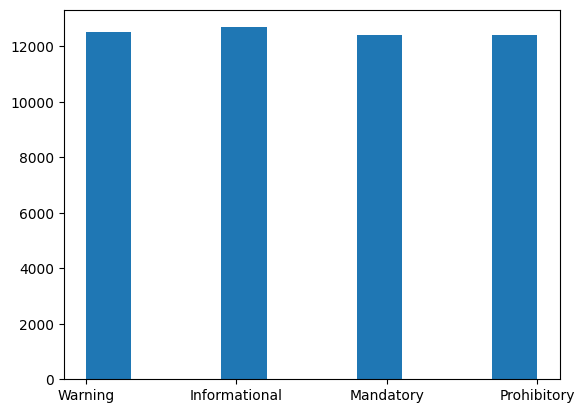

In [ ]:
plt.hist(df["label"])
plt.show()

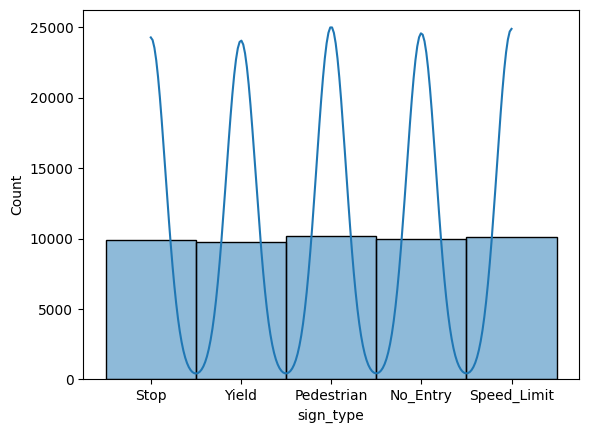

In [ ]:
sns.histplot(df["sign_type"],kde=True)
plt.show()

# Correlation analysis

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            50000 non-null  int64  
 1   width         50000 non-null  int64  
 2   height        50000 non-null  int64  
 3   brightness    50000 non-null  float64
 4   contrast      50000 non-null  float64
 5   hue           50000 non-null  float64
 6   saturation    50000 non-null  float64
 7   sign_type     50000 non-null  object 
 8   weather       50000 non-null  object 
 9   damage_level  50000 non-null  float64
 10  occlusion     50000 non-null  object 
 11  label         50000 non-null  object 
dtypes: float64(5), int64(3), object(4)
memory usage: 4.6+ MB


In [ ]:
print(df["sign_type"].unique())

['Stop' 'Yield' 'Pedestrian' 'No_Entry' 'Speed_Limit']


In [ ]:
print(df["weather"].unique())

['Cloudy' 'Foggy' 'Rainy' 'Sunny']


In [ ]:
print(df["occlusion"].unique())

['Low' 'Medium' 'High']


In [ ]:
print(df["label"].unique())

['Warning' 'Informational' 'Mandatory' 'Prohibitory']


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['sign_type']=le.fit_transform(df['sign_type'])
df['weather']=le.fit_transform(df['weather'])
df['occlusion']=le.fit_transform(df['occlusion'])
df['label']=le.fit_transform(df['label'])

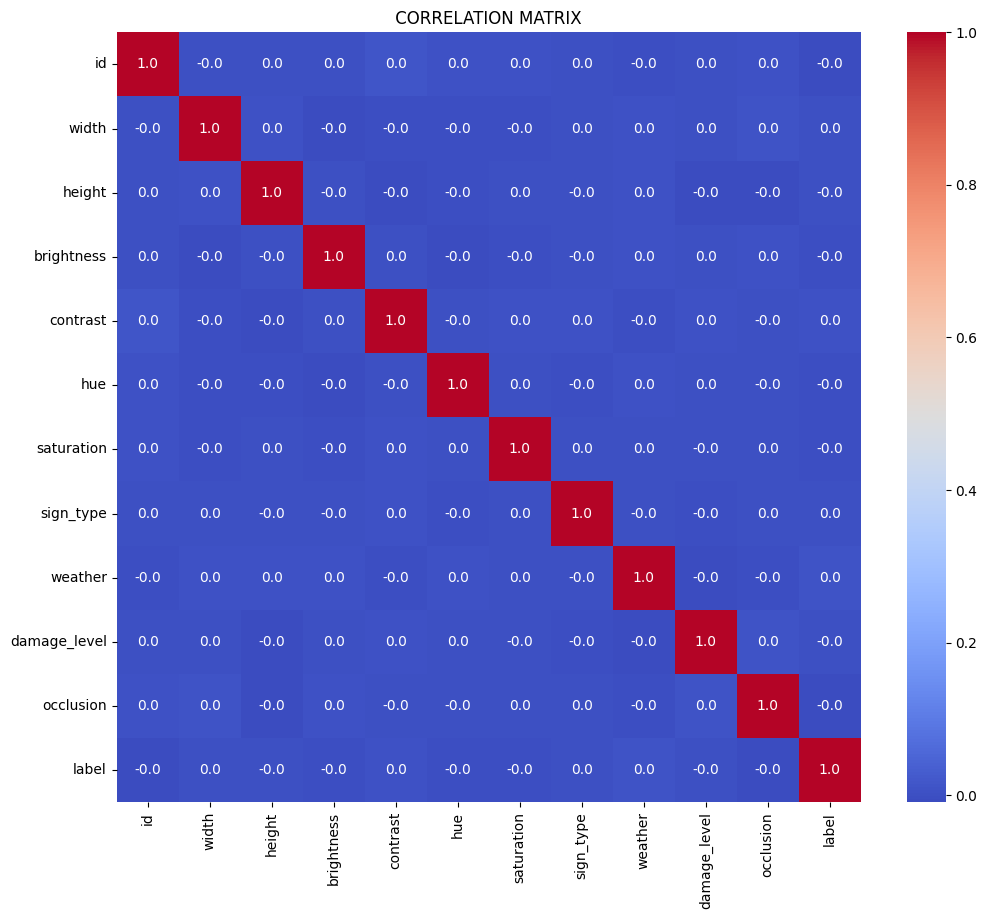

In [ ]:
corr_matrix=df.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix,annot=True,fmt="0.1f",cmap="coolwarm")
plt.title(" CORRELATION MATRIX ")
plt.show()

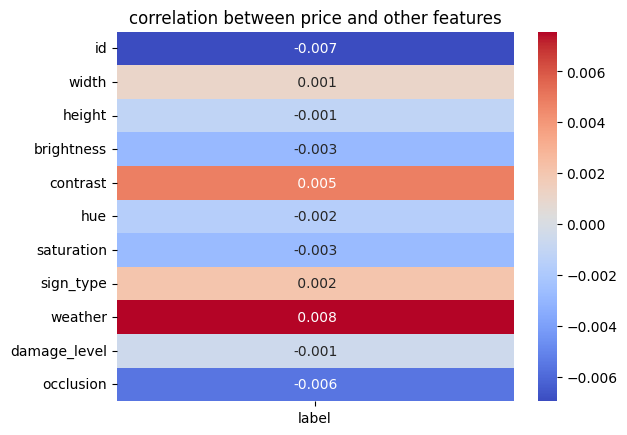

In [ ]:
status_corr=df.corr()["label"]
status_corr=status_corr.drop("label")
sns.heatmap(status_corr.to_frame(),annot=True,fmt=" .3f",cmap= "coolwarm",cbar=True,annot_kws={'size':10})
plt.title("correlation between price and other features")
plt.show()

In [ ]:
df.columns

Index(['id', 'width', 'height', 'brightness', 'contrast', 'hue', 'saturation',
       'sign_type', 'weather', 'damage_level', 'occlusion', 'label'],
      dtype='object')

In [ ]:
df.drop(['id','occlusion'],axis=1,inplace=True)

# Outlier Checking and removing

<Axes: >

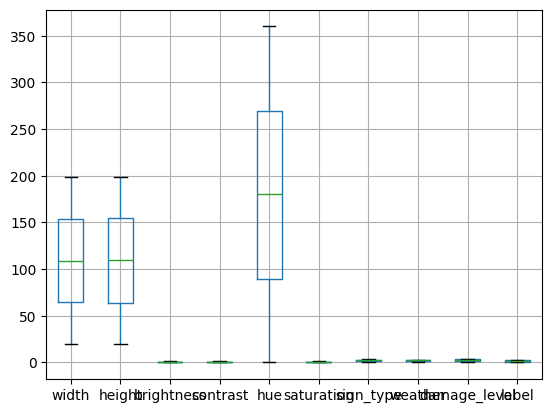

In [ ]:
df.boxplot()

In [ ]:
def remove_outliers_iqr(df, exclude_column):
  df_numeric = df.select_dtypes(include=np.number) # Select only numeric columns
  df_cleaned = df.copy() # Create a copy to modify

  for col in df_numeric.columns:
    if col == exclude_column:
      continue
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]
  return df_cleaned

df_cleaned= remove_outliers_iqr(df,exclude_column='label')
df=df_cleaned

In [ ]:
df.columns

Index(['width', 'height', 'brightness', 'contrast', 'hue', 'saturation',
       'sign_type', 'weather', 'damage_level', 'label'],
      dtype='object')

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
features =['width', 'height', 'brightness', 'contrast','hue','saturation',
       'sign_type','weather','damage_level']
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[features])
scaled_df = pd.DataFrame(scaled_data, columns=features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

x=df[['width', 'height', 'brightness', 'contrast','hue','saturation',
       'sign_type','weather','damage_level']]
y=df["label"]

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

model=LogisticRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.25


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# KFold

In [ ]:
from sklearn.model_selection import KFold

X=df[['width', 'height', 'brightness', 'contrast','hue','saturation',
       'sign_type','weather','damage_level']]
Y=df["label"]


# KFold setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model=LogisticRegression()

# Track best fold data
best_accuracy = 0
best_fold = -1


# Save best fold's data
best_X_train = None
best_y_train = None
best_X_test = None
best_y_test = None
best_y_pred = None

# Loop over each fold
for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Fold {fold} Accuracy: {acc}")

    # Update best fold
    if acc > best_accuracy:
        best_accuracy = acc
        best_fold = fold
        best_X_train = X_train
        best_y_train = y_train
        best_X_test = X_test
        best_y_test = y_test
        best_y_pred = y_pred
# Output best fold details
print(f"\n Best Fold: {best_fold} with Accuracy: {best_accuracy}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 1 Accuracy: 0.2493


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 2 Accuracy: 0.2495


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 3 Accuracy: 0.247


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 4 Accuracy: 0.244
Fold 5 Accuracy: 0.2436

 Best Fold: 2 with Accuracy: 0.2495


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# DECISION TREE

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.2436

# SVM - SVC

In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

model = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='linear'))
])

model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.2504

# RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.2425

# ADABOOST

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.2515

# XGBOOST

In [ ]:
from  xgboost import XGBClassifier
model = XGBClassifier()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.2509